In [1]:
#import all the libraries

from tensorflow.keras.layers import Input , Lambda, Dense,Flatten
from tensorflow.keras.models  import Model
from tensorflow.keras.applications.resnet50 import ResNet50 , preprocess_input 
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

2022-06-20 18:05:59.264481: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-20 18:05:59.264502: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
#re-size all the images

IMAGE_SIZE = [224, 224]

train_path = 'Datasets/train'
valid_path = 'Datasets/test'


In [4]:
#import the resnet50 library as shown below and add preprocessing layer to front of resnet50
#here we will use imagenet weights

resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)


# Supplying weights="imagenet" indicates that we want to use the pre-trained ImageNet weights
# for the respective model. 

2022-06-20 18:06:00.956218: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-06-20 18:06:00.956239: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-06-20 18:06:00.956252: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (RSPL-412): /proc/driver/nvidia/version does not exist
2022-06-20 18:06:00.956378: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
 resnet.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 56, 56, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 56, 56, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                  'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block1_add[0][0]']       
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 7, 7, 512)    1049088     ['conv5_block1_out[0][0]']       
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

In [6]:
#don't train existing weights

for layer in resnet.layers:
    layer.trainable = False


In [7]:
#useful for getting number 

folders = glob.glob('Datasets/Train/*')
folders

['Datasets/Train/audi',
 'Datasets/Train/mercedes',
 'Datasets/Train/lamborghini']

In [8]:
x = Flatten()(resnet.output)

In [18]:

prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=resnet.input, outputs=prediction)

In [19]:
print(len(folders))

3


In [20]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 56, 56, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 56, 56, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                  'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block1_add[0][0]']       
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 7, 7, 512)    1049088     ['conv5_block1_out[0][0]']       
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

In [21]:
#tell the model cost and optimization method to use
model.compile(
      loss = "categorical_crossentropy",
      optimizer = "adam",
      metrics = ["accuracy"]
)

In [22]:
#use the image data generator to import images from the dataset (data augmentation)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
         rescale = 1/255,
         shear_range= 0.2,
          zoom_range = 0.2,
         horizontal_flip = True
)


test_datagen = ImageDataGenerator(
      rescale = 1 255)

In [23]:
#make sure we should provide the same target size as initial for the image size

training_set = train_datagen.flow_from_directory(
    'Datasets/Train',
     target_size=(224,224),
     batch_size=8,
     class_mode="categorical"
)

#when we have more than 3 categories then we use categorical
#but if we have only two categories then we need to use binary

Found 64 images belonging to 3 classes.


In [24]:

test_set = train_datagen.flow_from_directory(
    'Datasets/Test',
     target_size=(224,224),
     batch_size=8,
     class_mode="categorical"
)


Found 58 images belonging to 3 classes.


In [25]:
#fit the model

r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=50,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)


Epoch 1/50
8/8 [==============================] - 5s 480ms/step - loss: 6.1783 - accuracy: 0.3594 - val_loss: 4.4202 - val_accuracy: 0.5172
Epoch 2/50
8/8 [==============================] - 3s 385ms/step - loss: 4.2308 - accuracy: 0.2969 - val_loss: 2.2767 - val_accuracy: 0.6034
Epoch 3/50
8/8 [==============================] - 3s 398ms/step - loss: 2.7028 - accuracy: 0.4844 - val_loss: 2.7158 - val_accuracy: 0.3276
Epoch 4/50
8/8 [==============================] - 3s 390ms/step - loss: 1.8757 - accuracy: 0.4844 - val_loss: 1.2723 - val_accuracy: 0.4828
Epoch 5/50
8/8 [==============================] - 3s 389ms/step - loss: 1.0196 - accuracy: 0.6719 - val_loss: 2.1489 - val_accuracy: 0.2931
Epoch 6/50
8/8 [==============================] - 3s 383ms/step - loss: 0.8654 - accuracy: 0.6406 - val_loss: 1.0708 - val_accuracy: 0.5690
Epoch 7/50
8/8 [==============================] - 3s 384ms/step - loss: 0.5045 - accuracy: 0.7656 - val_loss: 1.0241 - val_accuracy: 0.5862
Epoch 8/50
8/8 [====

In [26]:
r.history

{'loss': [6.178297519683838,
  4.230775833129883,
  2.702787399291992,
  1.8757433891296387,
  1.0196220874786377,
  0.8653604984283447,
  0.5044599175453186,
  0.45796963572502136,
  0.5907863974571228,
  0.8168849945068359,
  0.6534966230392456,
  0.390592098236084,
  0.5706179738044739,
  0.4309541583061218,
  0.5989139080047607,
  0.9337204098701477,
  1.2906043529510498,
  0.8643654584884644,
  1.0873010158538818,
  0.4700509309768677,
  0.4053928256034851,
  0.3870999217033386,
  0.2977437674999237,
  0.20342400670051575,
  0.29718536138534546,
  0.6550899147987366,
  0.9147521257400513,
  0.7289415597915649,
  0.22765322029590607,
  0.13753890991210938,
  0.17086975276470184,
  0.11598052829504013,
  0.22635409235954285,
  0.13556882739067078,
  0.13106435537338257,
  0.15938334167003632,
  0.27604007720947266,
  0.18963667750358582,
  0.1372305452823639,
  0.10190856456756592,
  0.09494710713624954,
  0.10259921848773956,
  0.09992664307355881,
  0.28809425234794617,
  0.169993

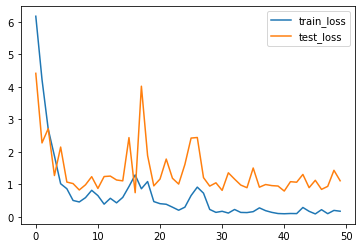

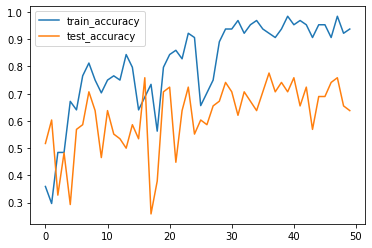

In [28]:
#plot the loss

plt.plot(r.history["loss"],label="train_loss")
plt.plot(r.history["val_loss"],label="test_loss")
plt.legend()
plt.show()


plt.plot(r.history["accuracy"],label="train_accuracy")
plt.plot(r.history["val_accuracy"],label="test_accuracy")
plt.legend()
plt.show()



In [29]:
y_pred = model.predict(test_set)

8/8 [==============================] - 2s 168ms/step


In [33]:
y_pred

array([[3.90901184e-03, 8.28838289e-01, 1.67252660e-01],
       [5.31420555e-05, 9.57564218e-04, 9.98989344e-01],
       [4.98668524e-03, 9.71346796e-01, 2.36664955e-02],
       [3.83316018e-02, 8.81740153e-01, 7.99282640e-02],
       [2.50707626e-01, 7.43856847e-01, 5.43557759e-03],
       [9.10407126e-01, 8.33486840e-02, 6.24428969e-03],
       [3.25744301e-01, 6.31853104e-01, 4.24026102e-02],
       [5.06421085e-03, 9.89166021e-01, 5.76971006e-03],
       [9.98123705e-01, 1.87599298e-03, 2.47328956e-07],
       [2.68359436e-05, 2.89932992e-02, 9.70979810e-01],
       [9.65091931e-06, 9.98446465e-01, 1.54401828e-03],
       [1.08152824e-02, 8.78322482e-01, 1.10862128e-01],
       [2.34689668e-01, 6.30787492e-01, 1.34522855e-01],
       [1.70133691e-02, 9.72689390e-01, 1.02971001e-02],
       [3.94526316e-04, 9.99567211e-01, 3.82234321e-05],
       [8.58016312e-02, 6.12573504e-01, 3.01624864e-01],
       [3.08955889e-02, 9.55004334e-01, 1.41001372e-02],
       [9.99715447e-01, 2.19803

In [34]:
y_pred = np.argmax(y_pred , axis=1)

In [36]:
y_pred

array([1, 2, 1, 1, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0])

In [41]:
img = image.load_img("Datasets/Test/audicarwallpaper.jpeg",target_size=(224,224))

In [55]:
x = image.img_to_array(img)



In [56]:
x = x/255

In [57]:
x.shape

(224, 224, 3)

In [58]:
x = np.expand_dims(x,axis=0)
x.shape

(1, 224, 224, 3)

In [62]:
img_data = preprocess_input(x)
model.predict(img_data)

1/1 [==============================] - 0s 38ms/step


array([[9.9979907e-01, 1.5026666e-11, 2.0100323e-04]], dtype=float32)

In [64]:
a = np.argmax(model.predict(img_data),axis =1)

1/1 [==============================] - 0s 44ms/step


In [67]:
if a ==0 :
    print("this car is audi")
elif a==1:
    print("this car is lamborgini")
elif a==3:
    print("this car is mercedes benz")

this car is baudi
